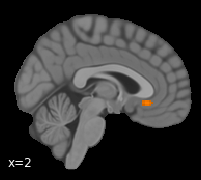

In [ ]:
# Sagittal view of DiFuMo sgACC (component 133) on high-res MNI with dark background
import numpy as np
import nibabel as nib
from nilearn import datasets, image, plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

# Load DiFuMo atlas (1024 components)
atlas = datasets.fetch_atlas_difumo(dimension=1024)

component_idx = 133  # sgACC
component_img = image.index_img(atlas.maps, component_idx)

# High-resolution MNI152 background (1 mm)
mni_bg = datasets.load_mni152_template(resolution=1)

# Find peak coordinate (in mm) for a clean sagittal cut
arr = component_img.get_fdata()
peak_vox = np.unravel_index(np.nanargmax(arr), arr.shape)
peak_mm = nib.affines.apply_affine(component_img.affine, peak_vox)

# Threshold at 90th percentile of positive weights to highlight parcel
positive = arr[arr > 0]
thr = np.percentile(positive, 90) if positive.size else 0

# Bright orange colormap for parcel
orange_cmap = LinearSegmentedColormap.from_list('bright_orange', ['#000000', '#ff7f00'])




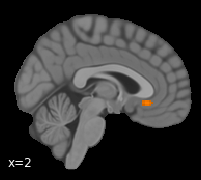

In [8]:

# Render sagittal slice with parcel shaded on black background, no text
plotting.plot_stat_map(
    component_img,
    bg_img=mni_bg,
    display_mode='x',
    cut_coords=[peak_mm[0]],
    threshold=thr,
    colorbar=False,
    cmap=orange_cmap,
    black_bg=True,
    title='',
)
plt.savefig('../figures/sgacc_sagittal.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()


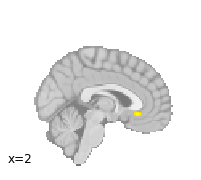

In [2]:

# Render sagittal slice with parcel shaded
plotting.plot_stat_map(
    component_img,
    display_mode='x',
    cut_coords=[peak_mm[0]],
    threshold=thr,
    colorbar=False,
    cmap='autumn',
    title=''
)

plt.savefig('../figures/sgacc_sagittal.png', dpi=300)
plt.show()
